In [51]:
%pip install json
%pip install pathlib
%pip install numpy
%pip install sys
%pip install cv2
%pip install pandas
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement json (from versions: none)
ERROR: No matching distribution found for json

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import json
from pathlib import Path
import numpy as np
import sys
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.widgets import Button
import ipywidgets as widgets
from IPython.display import display, clear_output


project_root = Path("..").resolve()
sys.path.append(str(project_root))
from Calibration.Parameters import CHAMBERS_COLORS

## Resultats sur l'ensemble des larves

In [53]:
tracking_folder = project_root / "Data"
tracking_files = list(tracking_folder.rglob("*tracking.json"))

print(len(tracking_files), "fichiers trouvés")

35 fichiers trouvés


In [54]:
sample_video = str(tracking_files[0]).replace("_tracking.json", ".mp4")
cap = cv2.VideoCapture(sample_video)
ret, frame = cap.read()
if not ret:
    raise ValueError(f"Impossible d'ouvrir la vidéo {sample_video}")
video_height, video_width = frame.shape[:2]
cap.release()
print(f"Taille vidéo : {video_width} x {video_height}")

Taille vidéo : 888 x 930


In [55]:
mask_path_top = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_top_painted.png"
mask_path_bottom = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_bottom_painted.png"

mask_top = cv2.imread(str(mask_path_top))
mask_bottom = cv2.imread(str(mask_path_bottom))
mask_top = cv2.cvtColor(mask_top, cv2.COLOR_BGR2RGB)
mask_bottom = cv2.cvtColor(mask_bottom, cv2.COLOR_BGR2RGB)


mask_top = cv2.resize(
    mask_top,
    (video_width, video_height),
    interpolation=cv2.INTER_NEAREST
)

mask_bottom = cv2.resize(
    mask_bottom,
    (video_width, video_height),
    interpolation=cv2.INTER_NEAREST
)

# Affichage de toutes les trajectoires en simultané

C:\Users\julie\AppData\Local\Temp\ipykernel_17184\1844637547.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('hsv', num_files)


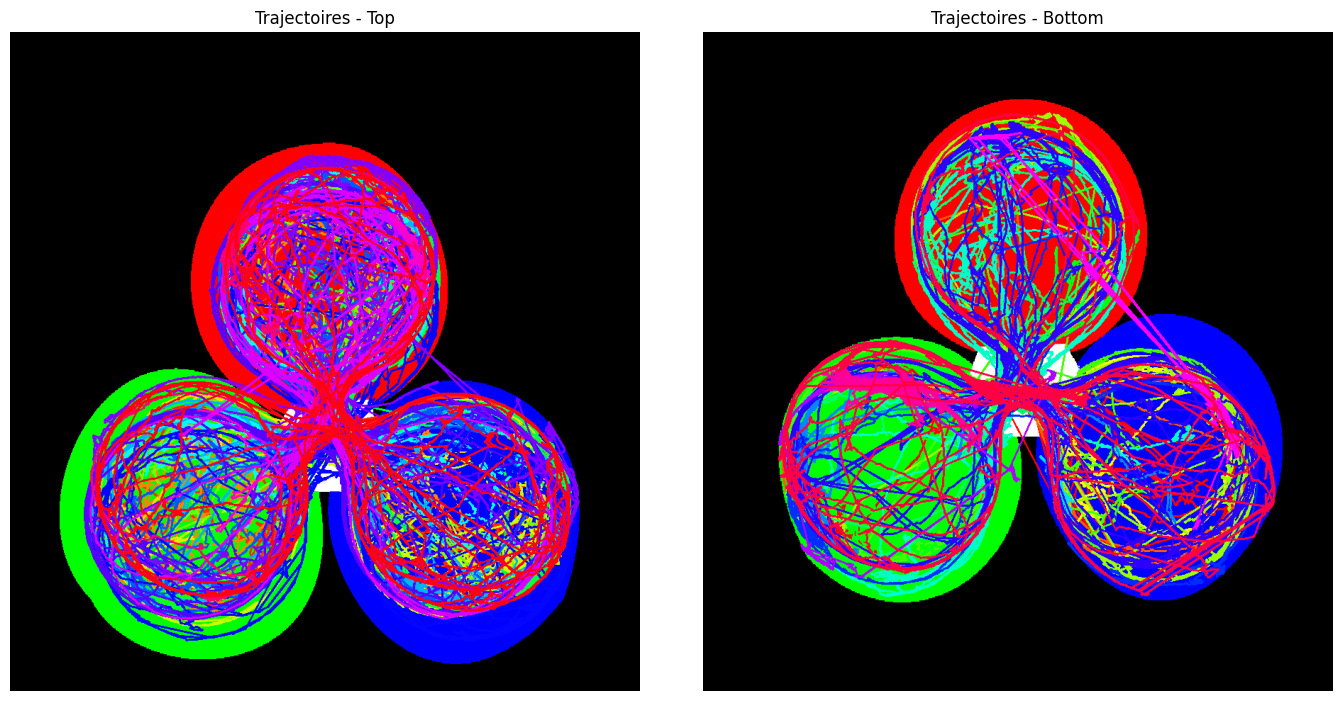

In [ ]:
def plot_trajectories(tracking_files, mask_top, mask_bottom, alpha=0.6, line_width=2):
    """Trace toutes les trajectoires sur les masques top et bottom."""
    
    mask_top_plot = mask_top.copy()
    mask_bottom_plot = mask_bottom.copy()
    
    num_files = len(tracking_files)
    colors = cm.get_cmap('hsv', num_files)
    
    for idx, file in enumerate(tracking_files):
        cancel_file = file.with_name(file.stem.replace("_tracking", "") + "_tracking_cancelled.txt")
        if cancel_file.exists():
            print(f"Vidéo ignorée (tracking annulé) : {file.stem}")
            continue
        
        with open(file) as f:
            data = json.load(f)
        
        df = data["tracking"]
        positions = [p for p in df if p["position"] is not None]
        if not positions:
            continue
        x_coords = [p["position"]["x"] for p in positions]
        y_coords = [p["position"]["y"] for p in positions]
        
        mask_plot = mask_top_plot if "_top" in str(file) else mask_bottom_plot
        color_rgb = tuple(int(255*c) for c in colors(idx)[:3])
        
        for i in range(1, len(x_coords)):
            pt1 = (int(x_coords[i-1]), int(y_coords[i-1]))
            pt2 = (int(x_coords[i]), int(y_coords[i]))
            cv2.line(mask_plot, pt1, pt2, color=color_rgb, thickness=line_width)
    
    return mask_top_plot, mask_bottom_plot


mask_top_plot, mask_bottom_plot = plot_trajectories(tracking_files, mask_top, mask_bottom)

fig, axes = plt.subplots(1,2, figsize=(14,7))
axes[0].imshow(mask_top_plot)
axes[0].set_title("Trajectoires - Top")
axes[0].axis("off")

axes[1].imshow(mask_bottom_plot)
axes[1].set_title("Trajectoires - Bottom")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Choix des fichiers à conserver

In [57]:
def build_chamber_map(mask_rgb):
    """
    Convertit un masque RGB en carte d'indices de chambres.

    Parameters
    ----------
    mask_rgb : np.ndarray
        Image RGB du masque (HxWx3)

    Returns
    -------
    chamber_map : np.ndarray
        Carte 2D (HxW) avec ID des chambres
    """

    # Mapping couleurs → ID
    COLOR_TO_ID = {
        (0, 0, 255): 1,   # Chambre_1
        (0, 255, 0): 2,   # Chambre_2
        (255, 0, 0): 3,   # Chambre_3
        (255, 255, 255): 4  # Decision_zone
    }

    height, width, _ = mask_rgb.shape
    chamber_map = np.zeros((height, width), dtype=np.uint8)

    # Remplir la carte
    for color, chamber_id in COLOR_TO_ID.items():
        mask_pixels = np.all(mask_rgb == color, axis=2)
        chamber_map[mask_pixels] = chamber_id

    return chamber_map

In [ ]:
class TrajectoryReviewer:
    def __init__(self, tracking_files, mask_top, mask_bottom):
        self.files = tracking_files
        self.mask_top = mask_top
        self.mask_bottom = mask_bottom
        self.chamber_map_top = build_chamber_map(mask_top)
        self.chamber_map_bottom = build_chamber_map(mask_bottom)

        self.idx = 0
        self.saved = []

        self.out = widgets.Output()
        self.label = widgets.HTML()

        self.btn_keep = widgets.Button(description="Garder", button_style='success')
        self.btn_skip = widgets.Button(description="Supprimer", button_style='danger')
        self.btn_back = widgets.Button(description="Retour")

        self.btn_keep.on_click(self.keep)
        self.btn_skip.on_click(self.skip)
        self.btn_back.on_click(self.back)

        self.ui = widgets.VBox([
            self.label,
            self.out,
            widgets.HBox([self.btn_keep, self.btn_skip, self.btn_back])
        ])

        display(self.ui)
        self.show()


    def compute_time_in_chambers(self, df, fps, chamber_map):
        df = df.copy()
        height, width = chamber_map.shape

        df["x_int"] = df["position"].apply(lambda p: p["x"] if p else None)
        df["y_int"] = df["position"].apply(lambda p: p["y"] if p else None)

        df["chamber_id"] = [
            chamber_map[y, x] if x is not None and y is not None and 0 <= x < width and 0 <= y < height else 0
            for x, y in zip(df["x_int"], df["y_int"])
        ]

        inverse_map = {
            0: "Outside",
            1: "Chambre_1",
            2: "Chambre_2",
            3: "Chambre_3",
            4: "Decision_zone"
        }

        df["chamber"] = df["chamber_id"].map(inverse_map)
        return df.groupby("chamber").size() / fps


    def plot_time_distribution(self, time_spent_sec):
        colors = {
            "Outside": "lightgray",
            "Chambre_1": "blue",
            "Chambre_2": "green",
            "Chambre_3": "red",
            "Decision_zone": "white"
        }

        sorted_times = time_spent_sec.sort_values()
        bar_colors = [colors[ch] for ch in sorted_times.index]

        plt.barh(sorted_times.index, sorted_times.values,
                 color=bar_colors, edgecolor='black')

        for i, v in enumerate(sorted_times.values):
            plt.text(v + 0.2, i, f"{v:.1f}s", va='center')

        plt.xlabel("Temps (s)")
        plt.title("Temps par chambre")

    def draw(self, file):
        with open(file) as f:
            data = json.load(f)

        df = pd.DataFrame(data["tracking"])
        fps = data["fps"]

        positions = [p for p in data["tracking"] if p["position"]]
        if not positions:
            return None, None, None, None

        x = [p["position"]["x"] for p in positions]
        y = [p["position"]["y"] for p in positions]

        if "_top" in str(file):
            mask = self.mask_top.copy()
            chamber_map = self.chamber_map_top
        else:
            mask = self.mask_bottom.copy()
            chamber_map = self.chamber_map_bottom

        for i in range(1, len(x)):
            cv2.line(mask, (x[i-1], y[i-1]), (x[i], y[i]), (0,0,0), 2)

        return mask, df, fps, chamber_map

    def show(self):
        while self.idx < len(self.files):
            file = self.files[self.idx]

            cancel_file = file.with_name(file.stem.replace("_tracking", "") + "_tracking_cancelled.txt")
            if cancel_file.exists():
                self.idx += 1
                continue

            img, df, fps, chamber_map = self.draw(file)

            if img is None:
                self.idx += 1
                continue

            time_spent = self.compute_time_in_chambers(df, fps, chamber_map)

            with self.out:
                clear_output(wait=True)

                plt.figure(figsize=(10,5))

                plt.subplot(1,2,1)
                plt.imshow(img)
                plt.title("Trajectoire")
                plt.gca().invert_yaxis()
                plt.axis("off")

                plt.subplot(1,2,2)
                self.plot_time_distribution(time_spent)

                plt.tight_layout()
                plt.show()

            self.label.value = f"<h3>{self.idx+1}/{len(self.files)} — {file.resolve()}</h3>"
            return

        self.finish()


    def keep(self, _):
        self.saved.append(self.files[self.idx])
        self.idx += 1
        self.show()

    def skip(self, _):
        self.idx += 1
        self.show()

    def back(self, _):
        if self.idx > 0:
            self.idx -= 1
            if self.files[self.idx] in self.saved:
                self.saved.remove(self.files[self.idx])
        self.show()

    def finish(self):
        clear_output()
        print(f"Terminé : {len(self.saved)} trajectoires gardées")

In [ ]:
reviewer = TrajectoryReviewer(
    tracking_files,
    mask_top,
    mask_bottom
)

kept_files = reviewer.saved

In [60]:
kept_files

[WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_11032026/Video/Mazes/Maze_A/Maze_A_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_11032026/Video/Mazes/Maze_A/Maze_A_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_11032026/Video/Mazes/Maze_B/Maze_B_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_11032026/Video/Mazes/Maze_B/Maze_B_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_11032026/Video/Mazes/Maze_C/Maze_C_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_11032026/Video/Mazes/Maze_C/Maze_C_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_11032026/Video/Mazes/Maze_D/Maze_D_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/E

In [65]:
all_times = {
    "Outside": [],
    "Chambre_1": [],
    "Chambre_2": [],
    "Chambre_3": [],
    "Decision_zone": []
}

for file in kept_files:
    with open(file) as f:
        data = json.load(f)
    df = pd.DataFrame(data["tracking"])
    fps = data["fps"]
    
    chamber_map = build_chamber_map(mask_top) if "_top" in str(file) else build_chamber_map(mask_bottom)
    
    times = reviewer.compute_time_in_chambers(df, fps, chamber_map)
    
    for chamber, t in times.items():
        all_times[chamber].append(t)

all_times = {
    "Outside": [],
    "Chambre_1": [],
    "Chambre_2": [],
    "Chambre_3": [],
    "Decision_zone": []
}

for file in kept_files:
    with open(file) as f:
        data = json.load(f)
    df = pd.DataFrame(data["tracking"])
    fps = data["fps"]
    
    chamber_map = build_chamber_map(mask_top) if "_top" in str(file) else build_chamber_map(mask_bottom)
    
    times = reviewer.compute_time_in_chambers(df, fps, chamber_map)
    
    for chamber, t in times.items():
        all_times[chamber].append(t)

mean_times = {ch: np.mean(times) if times else 0 for ch, times in all_times.items()}
std_times = {ch: np.std(times, ddof=1) if len(times) > 1 else 0 for ch, times in all_times.items()}

# Tracés et résultats

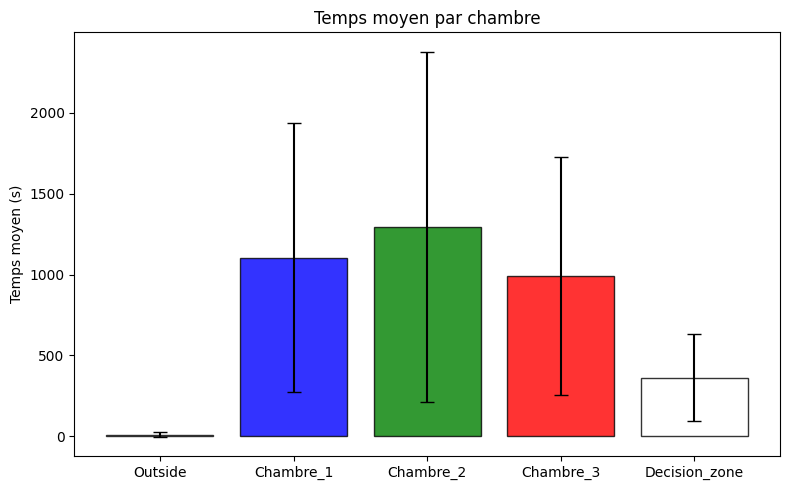

In [66]:
chambers = list(mean_times.keys())
means = [mean_times[ch] for ch in chambers]
stds = [std_times[ch] for ch in chambers]

colors = {
    "Outside": "lightgray",
    "Chambre_1": "blue",
    "Chambre_2": "green",
    "Chambre_3": "red",
    "Decision_zone": "white"
}
bar_colors = [colors[ch] for ch in chambers]

plt.figure(figsize=(8,5))
plt.bar(chambers, means, yerr=stds, color=bar_colors, edgecolor='black', alpha=0.8, capsize=5)
plt.ylabel("Temps moyen (s)")
plt.title("Temps moyen par chambre")
plt.tight_layout()
plt.show()

In [ ]:
transition_data = []

for file in kept_files:
    with open(file) as f:
        data = json.load(f)
    df = pd.DataFrame(data["tracking"])
    fps = data["fps"]
    
    chamber_map = build_chamber_map(mask_top) if "_top" in str(file) else build_chamber_map(mask_bottom)
    
    height, width = chamber_map.shape
    df["x_int"] = df["position"].apply(lambda p: p["x"] if p else None)
    df["y_int"] = df["position"].apply(lambda p: p["y"] if p else None)
    df["chamber_id"] = [
        chamber_map[y, x] if x is not None and y is not None and 0 <= x < width and 0 <= y < height else 0
        for x, y in zip(df["x_int"], df["y_int"])
    ]
    
    last_chamber = df["chamber_id"].iloc[0]
    time_in_chamber = 1 / fps
    for chamber in df["chamber_id"].iloc[1:]:
        if chamber == last_chamber:
            time_in_chamber += 1 / fps
        else:
            transition_data.append({
                "from": last_chamber,
                "to": chamber,
                "time_in_from": time_in_chamber
            })
            last_chamber = chamber
            time_in_chamber = 1 / fps

In [ ]:
import pandas as pd

df_transitions = pd.DataFrame(transition_data)

id_to_chamber = {0: "Outside", 1: "Chambre_1", 2: "Chambre_2", 3: "Chambre_3", 4: "Decision_zone"}
df_transitions["from_str"] = df_transitions["from"].map(id_to_chamber)
df_transitions["to_str"] = df_transitions["to"].map(id_to_chamber)

df_transitions.head()

,from,to,time_in_from,from_str,to_str
0,1,4,242.500000,Chambre_1,Decision_zone
1,4,1,5.333333,Decision_zone,Chambre_1
2,1,0,0.166667,Chambre_1,Outside
3,0,4,0.166667,Outside,Decision_zone
4,4,1,0.166667,Decision_zone,Chambre_1
